In [1]:
import torch
import torch.nn as nn
from torchvision import datasets , transforms
from torch.utils.data import DataLoader,random_split

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
from google.colab import files
uploaded = files.upload()

Saving dataset .zip to dataset .zip


In [4]:
import zipfile
zip_ref = zipfile.ZipFile('dataset .zip','r')
zip_ref.extractall('/content')
zip_ref.close()

import os
print(os.listdir())

['.config', 'dataset .zip', 'dataset ', '__MACOSX', 'sample_data']


In [5]:
transform = transforms.Compose(
    [

        transforms.Resize((224,224)),
        transforms.ToTensor()
    ]
)

dataset = datasets.ImageFolder(root='dataset ',transform=transform)

In [6]:
print(dataset.classes)

['Fake', 'Real']


In [7]:
train_size = int(0.8*len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset,[train_size , val_size])

In [8]:
train_loader = DataLoader(train_dataset ,batch_size = 32,shuffle = True)
val_loader = DataLoader(val_dataset ,batch_size = 32,shuffle = False)


In [9]:
from torchvision import models
import  torch.optim as optim

In [10]:
model= models.resnet18(pretrained = True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


In [11]:

model.fc = nn.Linear(model.fc.in_features, 2)
model.to(device)
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [12]:
optimizer  = optim.Adam(model.parameters(),lr = 0.0001)
criterion = nn.CrossEntropyLoss()

best_accuracy = 0

epochs = 40

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predictions = torch.max(outputs, 1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    train_accuracy = 100 * correct / total

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predictions = torch.max(outputs, 1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    val_accuracy = 100 * correct / total

    print(f"\nEpoch [{epoch+1}/{epochs}]")

    print(f"Train Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    if val_accuracy > best_accuracy:

        best_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_signature_model.pth"
        )

        print("Best model saved!")


Epoch [1/40]
Train Accuracy: 53.87%
Validation Accuracy: 58.90%
Best model saved!

Epoch [2/40]
Train Accuracy: 59.76%
Validation Accuracy: 67.02%
Best model saved!

Epoch [3/40]
Train Accuracy: 63.24%
Validation Accuracy: 66.23%

Epoch [4/40]
Train Accuracy: 66.58%
Validation Accuracy: 68.06%
Best model saved!

Epoch [5/40]
Train Accuracy: 67.56%
Validation Accuracy: 71.99%
Best model saved!

Epoch [6/40]
Train Accuracy: 70.38%
Validation Accuracy: 73.04%
Best model saved!

Epoch [7/40]
Train Accuracy: 70.45%
Validation Accuracy: 73.30%
Best model saved!

Epoch [8/40]
Train Accuracy: 70.64%
Validation Accuracy: 74.61%
Best model saved!

Epoch [9/40]
Train Accuracy: 71.82%
Validation Accuracy: 75.65%
Best model saved!

Epoch [10/40]
Train Accuracy: 72.21%
Validation Accuracy: 74.87%

Epoch [11/40]
Train Accuracy: 72.41%
Validation Accuracy: 75.65%

Epoch [12/40]
Train Accuracy: 73.79%
Validation Accuracy: 75.65%

Epoch [13/40]
Train Accuracy: 73.59%
Validation Accuracy: 76.18%
Best mo

Saving fake.png to fake (1).png
fake (1).png


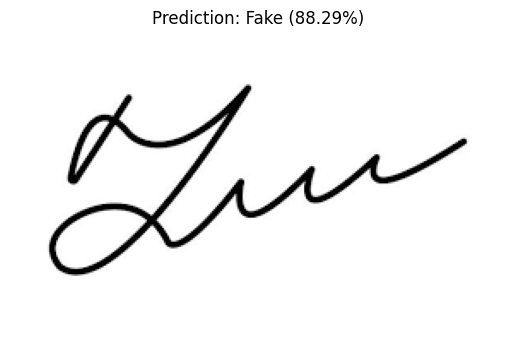

Prediction : Fake
Confidence : 88.29%


In [18]:
from google.colab import files
from PIL import Image

import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print(image_path)


model.load_state_dict(torch.load("best_signature_model.pth"))
model = model.to(device)

model.eval()


transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


original_image = Image.open(image_path).convert("RGB")

plt.imshow(original_image)
plt.axis("off")


image = transform(original_image).unsqueeze(0).to(device)

with torch.no_grad():

    outputs = model(image)

    probabilities = F.softmax(outputs, dim=1)

    confidence, prediction = torch.max(probabilities, 1)

    classes = ['Fake', 'Real']

    pred_class = classes[prediction.item()]
    conf = confidence.item() * 100


plt.title(f"Prediction: {pred_class} ({conf:.2f}%)")

plt.show()

print(f"Prediction : {pred_class}")
print(f"Confidence : {conf:.2f}%")